In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os,random

import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


seed = 666
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [20]:
import zipfile
with zipfile.ZipFile('/kaggle/input/dogs-vs-cats/train.zip', 'r') as zip_ref:
    zip_ref.extractall('train')
with zipfile.ZipFile('/kaggle/input/dogs-vs-cats/test1.zip', 'r') as zip_ref:
    zip_ref.extractall('test')

In [21]:
train_path='/kaggle/working/train/train/'
test_path='/kaggle/working/test/test1/'

In [22]:
train = os.listdir(train_path)
test = os.listdir(test_path)

In [23]:
train[0]

'cat.11195.jpg'

In [24]:
df = pd.DataFrame({"img_path":train,"label":[train[i][:3] for i in range(len(train))]})

In [25]:
def read_image_cv(file_name):
    image = cv2.imread(file_name)
    image = cv2.resize(image, (260,260))
    return image[:,:,:3]

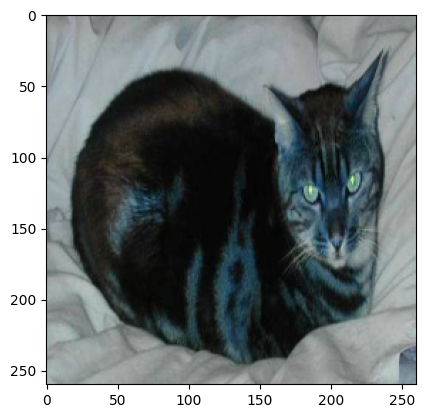

In [26]:
plt.imshow(read_image_cv(train_path+df['img_path'][0]))

In [27]:
len(train),len(test)

(25000, 12500)

In [28]:
from tensorflow.keras.applications import EfficientNetV2B2
from sklearn.model_selection import train_test_split

In [29]:
df['img_path'] = train_path+df['img_path']

In [30]:
train_x,val_x, train_y,val_y = train_test_split(df['img_path'],df['label'],test_size=0.3,shuffle=True, random_state=666)

In [31]:
train_x = np.stack(train_x.apply(read_image_cv))
val_x = np.stack(val_x.apply(read_image_cv))

In [32]:
train_y = pd.get_dummies(train_y)
val_y =pd.get_dummies(val_y)

In [33]:
inp = tf.keras.Input(shape=(260,260,3))
base = EfficientNetV2B2(weights='imagenet',include_top=False,input_tensor=inp)
for layer in base.layers:
    layer.trainable = False
x = base.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(1)(x)
x = tf.keras.layers.Activation('sigmoid')(x)

eff_model = tf.keras.Model(inputs=inp,outputs=x)

In [34]:
# eff_model.summary()

In [35]:
eff_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history = eff_model.fit(train_x,train_y,validation_data=[val_x,val_y],epochs=2)

Epoch 1/2


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 2), output.shape=(None, 1)

In [ ]:
def read_image_cv_test(file_name):
    image = cv2.imread(file_name)
    image = cv2.resize(image, (260,260))
    image = np.expand_dims(image, axis=0)
    return image

In [ ]:
test_img = read_image_cv_test(test_path + test[0])
pred = eff_model.predict(test_img)

In [ ]:
# Create subplots
fig, axes = plt.subplots(10,2, figsize=(15, 25))
axes = axes.flatten()

for i in range(20):
    test_img = read_image_cv_test(test_path + test[i])
    pred = eff_model.predict(test_img)
    
    # Display the image
    axes[i].imshow(read_image_cv(test_path + test[i]))  # Remove batch dimension for display
    
    # Annotate the image
    if pred[0][0] < pred[0][1]:
        axes[i].text(10, 10, 'dog', color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    else:
        axes[i].text(10, 10, 'cat', color='white', fontsize=12, bbox=dict(facecolor='blue', alpha=0.5))
    
    axes[i].axis('off')

plt.tight_layout()
plt.show()